# Generalized Linear Model

In [1]:
# group-lasso is loaded in the setup cell below.


In [2]:
from pathlib import Path
import warnings
import shutil
import time
import gc

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from group_lasso import GroupLasso
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)

DEVICE_PREFERENCE = "auto"  # one of: auto, cpu, cuda, mps


def resolve_device(preference: str):
    """Resolve the execution device from a simple notebook config flag."""
    preference = preference.lower()
    has_cuda = torch.cuda.is_available()
    has_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_built()
    mps_available = has_mps and torch.backends.mps.is_available()

    if preference == "auto":
        if has_cuda:
            return torch.device("cuda")
        if mps_available:
            return torch.device("mps")
        return torch.device("cpu")

    if preference == "cuda":
        if not has_cuda:
            raise RuntimeError("CUDA requested but is not available.")
        return torch.device("cuda")

    if preference == "mps":
        if not mps_available:
            raise RuntimeError("MPS requested but is not available.")
        return torch.device("mps")

    if preference == "cpu":
        return torch.device("cpu")

    raise ValueError(f"Unknown DEVICE_PREFERENCE={preference!r}")


DEVICE = resolve_device(DEVICE_PREFERENCE)

if getattr(DEVICE, "type", None) == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")
print(f"Device preference: {DEVICE_PREFERENCE}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if getattr(DEVICE, "type", None) == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"CUDA device: {props.name} ({props.total_memory / 1024**3:.1f} GB)")


Using device: cuda
Device preference: auto
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA L4 (22.0 GB)
Note: this GroupLasso implementation is CPU-based; DEVICE is available for compatible extensions.


### 1. Configuration

In [3]:
PANEL_FILE_NAME = "gkx2020_panel_trimmed.parquet"
TARGET = "ret_excess"
LAMBDA_GRID = [1e-4, 1e-3, 1e-2, 1e-1]
VALIDATION_WINDOW_YEARS = 12
START_TEST_YEAR = 1987
END_TEST_YEAR = 2021

DRIVE_DATA_DIR = Path("/content/drive/MyDrive/Replication Paper/Data")
LOCAL_DATA_DIR = Path("/content/data")
DRIVE_FILE = DRIVE_DATA_DIR / PANEL_FILE_NAME
LOCAL_FILE = LOCAL_DATA_DIR / PANEL_FILE_NAME
PATH = str(LOCAL_FILE)


### 2. Data Loading

In [4]:
print("Initializing lazy dataset...")

# ====================================================
# Mount Google Drive and copy the panel to local Colab
# runtime storage. Reading from /content/data is much
# faster and more stable than streaming from Drive.
# ====================================================
RUNNING_IN_COLAB = Path("/content").exists()
if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

if RUNNING_IN_COLAB:
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not DRIVE_FILE.exists():
        raise FileNotFoundError(f"File not found in Google Drive: {DRIVE_FILE}")
    if not LOCAL_FILE.exists():
        print("Copying panel from Google Drive to local Colab runtime...")
        shutil.copy2(DRIVE_FILE, LOCAL_FILE)
        print("Copy complete.")
    else:
        print("Local panel copy already exists. Skipping copy.")
else:
    LOCAL_DATA_DIR = Path("data")
    LOCAL_FILE = LOCAL_DATA_DIR / PANEL_FILE_NAME
    if not LOCAL_FILE.exists():
        raise FileNotFoundError(
            f"Local panel not found: {LOCAL_FILE}. In Colab this notebook expects {DRIVE_FILE}."
        )

PATH = str(LOCAL_FILE)
print(f"Using panel: {PATH}")

# (1) Lazy loading + (2) year kolom toevoegen
df_lazy = (
    pl.scan_parquet(PATH)
    .with_columns([
        pl.col(pl.NUMERIC_DTYPES).fill_null(0),
        pl.col("date").dt.year().alias("year")
    ])
)

# Feature columns bepalen (1x kleine collect)
df_sample = df_lazy.select(pl.all()).limit(1).collect()
non_feature_cols = ["date", "permno", "me", "exchcd", TARGET, "year", "split"]
feature_cols = [c for c in df_sample.columns if c not in non_feature_cols]

panel_summary = df_lazy.select([
    pl.len().alias("n_rows"),
    pl.col("date").min().alias("start_date"),
    pl.col("date").max().alias("end_date"),
    pl.col("permno").n_unique().alias("unique_stocks"),
]).collect()

print(panel_summary)
print(f"Total features: {len(feature_cols)}")


Mounted at /content/drive
Copying panel from Google Drive to local Colab runtime...
Copy complete.
Using panel: /content/data/gkx2020_panel_trimmed.parquet
shape: (1, 4)
┌─────────┬─────────────────────┬─────────────────────┬───────────────┐
│ n_rows  ┆ start_date          ┆ end_date            ┆ unique_stocks │
│ ---     ┆ ---                 ┆ ---                 ┆ ---           │
│ u32     ┆ datetime[ns]        ┆ datetime[ns]        ┆ u32           │
╞═════════╪═════════════════════╪═════════════════════╪═══════════════╡
│ 3305648 ┆ 1957-03-01 00:00:00 ┆ 2021-12-01 00:00:00 ┆ 25770         │
└─────────┴─────────────────────┴─────────────────────┴───────────────┘
Total features: 278


### 3. Helper Functions

In [5]:
#  Float32 casting (blijft belangrijk)
def cast_float32(df):
    return df.select([
        pl.col(c).cast(pl.Float32) if df[c].dtype == pl.Float64 else pl.col(c)
        for c in df.columns
    ])

def r2_oos(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / np.sum(y_true**2)

#  (5) Snellere spline functie (vectorized)
def get_gkx_spline_k3(X, spline_mask=None):
    X = np.asarray(X, dtype=np.float32)

    if spline_mask is None:
        hinge_square = np.maximum(0, X) ** 2
    else:
        spline_mask = np.asarray(spline_mask, dtype=bool)
        if spline_mask.shape[0] != X.shape[1]:
            raise ValueError("spline_mask must have one entry per raw feature.")
        hinge_square = np.zeros_like(X, dtype=np.float32)
        hinge_square[:, spline_mask] = np.maximum(0, X[:, spline_mask]) ** 2

    out = np.empty((X.shape[0], 1 + 2 * X.shape[1]), dtype=np.float32)
    out[:, 0] = 1.0
    out[:, 1::2] = X
    out[:, 2::2] = hinge_square
    return out


def standardize_spline_design(X_train, *other_mats):
    """Scale all non-intercept spline columns using train-period moments."""
    scaler = StandardScaler(copy=False)
    X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:]).astype(np.float32, copy=False)
    transformed = [X_train]

    for X in other_mats:
        X[:, 1:] = scaler.transform(X[:, 1:]).astype(np.float32, copy=False)
        transformed.append(X)

    return (*transformed, scaler)



class GPUGroupLassoFISTA:
    """GPU-backed group lasso solver with a GroupLasso-like notebook API.

    Minimizes 0.5 / n * ||X beta - y||^2 + group_reg * sum_g ||beta_g||_2.
    Group 0 is treated as unpenalized, which matches the intercept column in
    get_gkx_spline_k3().
    """

    def __init__(
        self,
        groups,
        group_reg=1e-3,
        tol=1e-2,
        device=None,
        max_iter=250,
        power_iter=12,
        predict_batch_size=262_144,
        verbose=False,
    ):
        self.groups = np.asarray(groups)
        self.group_reg = float(group_reg)
        self.tol = float(tol)
        self.device = torch.device(device if device is not None else "cuda" if torch.cuda.is_available() else "cpu")
        self.max_iter = int(max_iter)
        self.power_iter = int(power_iter)
        self.predict_batch_size = int(predict_batch_size)
        self.verbose = verbose
        self.coef_ = None
        self.n_iter_ = 0
        self.lipschitz_ = None

    def _group_indices(self, n_features):
        if len(self.groups) != n_features:
            raise ValueError(
                f"groups has length {len(self.groups):,}, but X has {n_features:,} columns."
            )
        indices = []
        for group_id in np.unique(self.groups):
            if group_id == 0:
                continue
            idx = np.flatnonzero(self.groups == group_id)
            if len(idx):
                indices.append(torch.as_tensor(idx, dtype=torch.long, device=self.device))
        return indices

    def _estimate_lipschitz(self, X):
        n_samples, n_features = X.shape
        v = torch.ones(n_features, dtype=X.dtype, device=self.device)
        v = v / torch.clamp(torch.linalg.vector_norm(v), min=1e-12)

        eig = torch.tensor(1.0, dtype=X.dtype, device=self.device)
        for _ in range(self.power_iter):
            Xv = X.matmul(v)
            XtXv = X.T.matmul(Xv) / n_samples
            eig = torch.linalg.vector_norm(XtXv)
            if eig <= 1e-12:
                break
            v = XtXv / eig

        Xv = X.matmul(v)
        eig = torch.dot(Xv, Xv) / n_samples
        return float(torch.clamp(eig, min=1e-8).detach().cpu())

    def _prox_group_lasso(self, beta, step_size, group_indices):
        out = beta.clone()
        threshold = step_size * self.group_reg
        for idx in group_indices:
            block = out[idx]
            norm = torch.linalg.vector_norm(block)
            if norm <= threshold:
                out[idx] = 0.0
            else:
                out[idx] = block * (1.0 - threshold / norm)
        return out

    def fit(self, X, y):
        X_np = np.asarray(X, dtype=np.float32, order="C")
        y_np = np.asarray(y, dtype=np.float32).reshape(-1)
        if X_np.shape[0] != y_np.shape[0]:
            raise ValueError("X and y have incompatible row counts.")

        X_t = torch.as_tensor(X_np, dtype=torch.float32, device=self.device)
        y_t = torch.as_tensor(y_np, dtype=torch.float32, device=self.device)
        n_samples, n_features = X_t.shape
        group_indices = self._group_indices(n_features)

        # === Gram matrix precomputation (the one-time expensive step) ===
        XtX = X_t.T.matmul(X_t)      # (p, p), e.g. 557 x 557
        Xty = X_t.T.matmul(y_t)      # (p,)
        yty = float(y_t.dot(y_t))    # scalar, kept for loss monitoring

        # Free the big X/y tensors - no longer needed during FISTA
        del X_t, y_t
        if self.device.type == "cuda":
            torch.cuda.empty_cache()

        # Exact Lipschitz constant = largest eigenvalue of XtX / n
        L = float(torch.linalg.eigvalsh(XtX / n_samples)[-1].clamp(min=1e-8))
        self.lipschitz_ = L
        step_size = 1.0 / L

        beta = torch.zeros(n_features, dtype=torch.float32, device=self.device)
        z = beta.clone()
        momentum = 1.0

        for iteration in range(1, self.max_iter + 1):
            # === The key speedup: O(p^2) instead of O(n*p) ===
            grad = (XtX.matmul(z) - Xty) / n_samples
            beta_next = self._prox_group_lasso(z - step_size * grad, step_size, group_indices)

            rel_change = torch.linalg.vector_norm(beta_next - beta) / torch.clamp(
                torch.linalg.vector_norm(beta), min=1e-8
            )
            momentum_next = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * momentum * momentum))
            z = beta_next + ((momentum - 1.0) / momentum_next) * (beta_next - beta)
            beta = beta_next
            momentum = momentum_next
            self.n_iter_ = iteration

            if self.verbose and (iteration == 1 or iteration % 25 == 0):
                # Full loss: 0.5/n * (beta^T XtX beta - 2 beta^T Xty + yty)
                loss = 0.5 * (beta.dot(XtX.matmul(beta)) - 2.0 * beta.dot(Xty) + yty).item() / n_samples
                print(f"    FISTA iter={iteration:>4} loss={loss:.6e} rel_change={rel_change.item():.3e}")

            if iteration > 1 and rel_change.item() < self.tol:
                break

        self.coef_ = beta.detach().cpu().numpy().reshape(-1, 1)

        del beta, z, XtX, Xty
        if self.device.type == "cuda":
            torch.cuda.empty_cache()
        return self

    def predict(self, X):
        if self.coef_ is None:
            raise RuntimeError("Model must be fit before calling predict().")

        X_np = np.asarray(X, dtype=np.float32, order="C")
        coef_t = torch.as_tensor(
            self.coef_.reshape(-1), dtype=torch.float32, device=self.device
        )
        preds = []

        with torch.inference_mode():
            for start in range(0, X_np.shape[0], self.predict_batch_size):
                stop = start + self.predict_batch_size
                X_batch = torch.as_tensor(X_np[start:stop], dtype=torch.float32, device=self.device)
                preds.append(X_batch.matmul(coef_t).detach().cpu().numpy())

        if self.device.type == "cuda":
            torch.cuda.empty_cache()
        return np.concatenate(preds).reshape(-1, 1)


def compute_vi_r2_reduction(model, X_sample, y_sample, feature_names):
    y_pred_base = model.predict(X_sample).flatten()
    r2_base = r2_oos(y_sample, y_pred_base)
    vi = {}

    for i, col in enumerate(feature_names):
        X_mutated = X_sample.copy()
        X_mutated[:, (i * 2) + 1 : (i * 2) + 3] = 0
        r2_mutated = r2_oos(y_sample, model.predict(X_mutated).flatten())
        vi[col] = max(0, r2_base - r2_mutated)

    return pd.Series(vi)

def plot_model_selection_over_time(years, counts):
    plt.figure(figsize=(10, 5))
    plt.plot(years, counts, linestyle='-', linewidth=2)
    plt.title("GLM + H")
    plt.ylabel("# of Char.")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, len(feature_cols) + 1)
    plt.show()


### 4. Data Preperation

In [7]:
groups = np.array([0] + [i + 1 for i in range(len(feature_cols)) for _ in range(2)])

# One-hot industry dummies should stay linear. If I spline-transform rare
# 0/1 dummies after z-scoring, the positive cases become huge leverage points.
spline_feature_mask = np.array([not c.startswith("ind_") for c in feature_cols], dtype=bool)
print(
    f"Spline basis: {spline_feature_mask.sum()} continuous/interacted features; "
    f"{len(feature_cols) - spline_feature_mask.sum()} industry dummies kept linear."
)
assert get_gkx_spline_k3(
    np.zeros((1, len(feature_cols)), dtype=np.float32),
    spline_feature_mask,
).shape[1] == len(groups)

VI_SAMPLE_PER_YEAR = 10_000  # set to None for exact, slower OOS VI
vi_rng = np.random.default_rng(42)
vi_weighted_sum = pd.Series(0.0, index=feature_cols, dtype=np.float64)
vi_sst_total = 0.0

all_preds, all_actuals, all_years = [], [], []
all_test_dates, all_test_me, all_test_permno, all_test_exchcd = [], [], [], []
all_test_best_lam, all_test_active_features = [], []
features_selected_count = []


Spline basis: 188 continuous/interacted features; 90 industry dummies kept linear.


### 5. Recursive Estimation Loop

In [8]:
print("Starting recursive estimation loop...")
run_start_time = time.time()
total_years = END_TEST_YEAR - START_TEST_YEAR + 1

for year in range(START_TEST_YEAR, END_TEST_YEAR + 1):
    year_start_time = time.time()
    val_start_year = year - VALIDATION_WINDOW_YEARS
    year_idx = year - START_TEST_YEAR + 1

    print("\n" + "=" * 72, flush=True)
    print(f"[{year_idx}/{total_years}] Processing test year {year}", flush=True)
    print(
        f"Train: < {val_start_year} | Valid: {val_start_year}-{year - 1} | Test: {year}",
        flush=True,
    )

    #  (1) Lazy filtering per subset
    train_df = cast_float32(
        df_lazy.filter(pl.col("year") < val_start_year).collect()
    )
    valid_df = cast_float32(
        df_lazy.filter((pl.col("year") >= val_start_year) & (pl.col("year") < year)).collect()
    )
    test_df = cast_float32(
        df_lazy.filter(pl.col("year") == year).collect()
    )

    if test_df.height == 0:
        print(f"No test observations for {year}; skipping.", flush=True)
        continue

    print(
        f"Rows loaded: train={train_df.height:,}, valid={valid_df.height:,}, test={test_df.height:,}",
        flush=True,
    )

    #  (3) to_numpy zonder kopie
    X_train_raw = train_df.select(feature_cols).to_numpy()
    X_valid_raw = valid_df.select(feature_cols).to_numpy()
    X_test_raw  = test_df.select(feature_cols).to_numpy()

    y_train = train_df[TARGET].to_numpy()
    y_valid = valid_df[TARGET].to_numpy()
    y_test  = test_df[TARGET].to_numpy()

    raw_scaler = StandardScaler(copy=False)
    X_train_scaled = raw_scaler.fit_transform(X_train_raw).astype(np.float32, copy=False)
    X_valid_scaled = raw_scaler.transform(X_valid_raw).astype(np.float32, copy=False)
    X_test_scaled  = raw_scaler.transform(X_test_raw).astype(np.float32, copy=False)

    X_train_spline = get_gkx_spline_k3(X_train_scaled, spline_feature_mask)
    X_valid_spline = get_gkx_spline_k3(X_valid_scaled, spline_feature_mask)
    X_test_spline  = get_gkx_spline_k3(X_test_scaled, spline_feature_mask)
    X_train_spline, X_valid_spline, X_test_spline, spline_scaler = standardize_spline_design(
        X_train_spline,
        X_valid_spline,
        X_test_spline,
    )

    spline_memory_gb = (
        X_train_spline.nbytes + X_valid_spline.nbytes + X_test_spline.nbytes
    ) / 1024**3
    print(
        f"Feature matrix: raw={X_train_raw.shape[1]:,} cols, spline={X_train_spline.shape[1]:,} cols | "
        f"spline memory approx={spline_memory_gb:.2f} GB",
        flush=True,
    )

    # Hyperparameter tuning
    best_lam, best_mse = 1e-4, np.inf
    lambda_results = []

    for lam in LAMBDA_GRID:
        lam_start_time = time.time()
        model = GPUGroupLassoFISTA(groups=groups, group_reg=lam, tol=5e-2, device=DEVICE)
        model.fit(X_train_spline, y_train.reshape(-1, 1))

        preds = model.predict(X_valid_spline).flatten()
        mse = np.mean((y_valid - preds) ** 2)

        lam_seconds = time.time() - lam_start_time
        lambda_results.append((lam, mse, lam_seconds))
        print(
            f"  lambda={lam:.1e} | valid MSE={mse:.6e} | elapsed={lam_seconds/60:.1f} min",
            flush=True,
        )

        if mse < best_mse:
            best_mse, best_lam = mse, lam

        del model
        gc.collect()

    # Final fit
    X_final_train = np.vstack([X_train_spline, X_valid_spline])
    y_final_train = np.concatenate([y_train, y_valid])

    final_fit_start_time = time.time()
    final_model = GPUGroupLassoFISTA(groups=groups, group_reg=best_lam, tol=1e-2, device=DEVICE)
    final_model.fit(X_final_train, y_final_train.reshape(-1, 1))
    final_fit_seconds = time.time() - final_fit_start_time

    # Sparsity
    coefs = final_model.coef_.flatten()[1:]
    active = sum(
        1 for i in range(len(feature_cols))
        if np.linalg.norm(coefs[i*2:i*2+2]) > 1e-8
    )
    features_selected_count.append(active)

    # Predictions
    y_pred = final_model.predict(X_test_spline).flatten()

    if VI_SAMPLE_PER_YEAR is not None and X_test_spline.shape[0] > VI_SAMPLE_PER_YEAR:
        vi_idx = vi_rng.choice(X_test_spline.shape[0], size=VI_SAMPLE_PER_YEAR, replace=False)
        X_vi = X_test_spline[vi_idx]
        y_vi = y_test[vi_idx]
    else:
        X_vi = X_test_spline
        y_vi = y_test

    year_vi = compute_vi_r2_reduction(final_model, X_vi, y_vi, feature_cols)
    year_sst = float(np.sum(y_test ** 2))
    vi_weighted_sum = vi_weighted_sum.add(year_vi * year_sst, fill_value=0.0)
    vi_sst_total += year_sst

    all_preds.extend(y_pred)
    all_actuals.extend(y_test)
    all_years.append(year)

    all_test_dates.extend(test_df["date"].to_numpy())
    all_test_me.extend(test_df["me"].to_numpy())
    all_test_permno.extend(test_df["permno"].to_numpy())
    if "exchcd" in test_df.columns:
        all_test_exchcd.extend(test_df["exchcd"].to_numpy())
    else:
        all_test_exchcd.extend([np.nan] * test_df.height)
    all_test_best_lam.extend([best_lam] * test_df.height)
    all_test_active_features.extend([active] * test_df.height)

    year_r2 = r2_oos(y_test, y_pred)
    year_seconds = time.time() - year_start_time
    total_seconds = time.time() - run_start_time
    print(
        f"Year {year} complete | R2={year_r2:.4%} | best lambda={best_lam:.1e} "
        f"(valid MSE={best_mse:.6e}) | active features={active:,}/{len(feature_cols):,}",
        flush=True,
    )
    print(
        f"Predictions: n={len(y_pred):,}, mean={np.mean(y_pred):.6e}, std={np.std(y_pred):.6e} | "
        f"final fit={final_fit_seconds/60:.1f} min | year elapsed={year_seconds/60:.1f} min | "
        f"total elapsed={total_seconds/60:.1f} min | cumulative rows={len(all_preds):,}",
        flush=True,
    )

    X_test_spline_last = X_test_spline
    y_test_last = y_test
    raw_scaler_last = raw_scaler
    spline_scaler_last = spline_scaler

    del train_df, valid_df, test_df
    del X_train_raw, X_valid_raw, X_test_raw
    del X_train_spline, X_valid_spline, X_test_spline
    del X_final_train
    gc.collect()


Starting recursive estimation loop...

[1/35] Processing test year 1987
Train: < 1975 | Valid: 1975-1986 | Test: 1987
Rows loaded: train=454,192, valid=714,540, test=73,957
Feature matrix: raw=278 cols, spline=557 cols | spline memory approx=2.58 GB
  lambda=1.0e-04 | valid MSE=2.806298e-02 | elapsed=0.0 min
  lambda=1.0e-03 | valid MSE=2.745834e-02 | elapsed=0.0 min
  lambda=1.0e-02 | valid MSE=2.636390e-02 | elapsed=0.0 min
  lambda=1.0e-01 | valid MSE=2.637286e-02 | elapsed=0.0 min
Year 1987 complete | R2=-0.0199% | best lambda=1.0e-02 (valid MSE=2.636390e-02) | active features=7/278
Predictions: n=73,957, mean=1.339080e-03, std=1.678868e-03 | final fit=0.1 min | year elapsed=0.4 min | total elapsed=0.4 min | cumulative rows=73,957

[2/35] Processing test year 1988
Train: < 1976 | Valid: 1976-1987 | Test: 1988
Rows loaded: train=509,094, valid=733,595, test=73,664
Feature matrix: raw=278 cols, spline=557 cols | spline memory approx=2.73 GB
  lambda=1.0e-04 | valid MSE=2.687771e-02 |

### 6. Visualizations


Calculating Variable Importance...


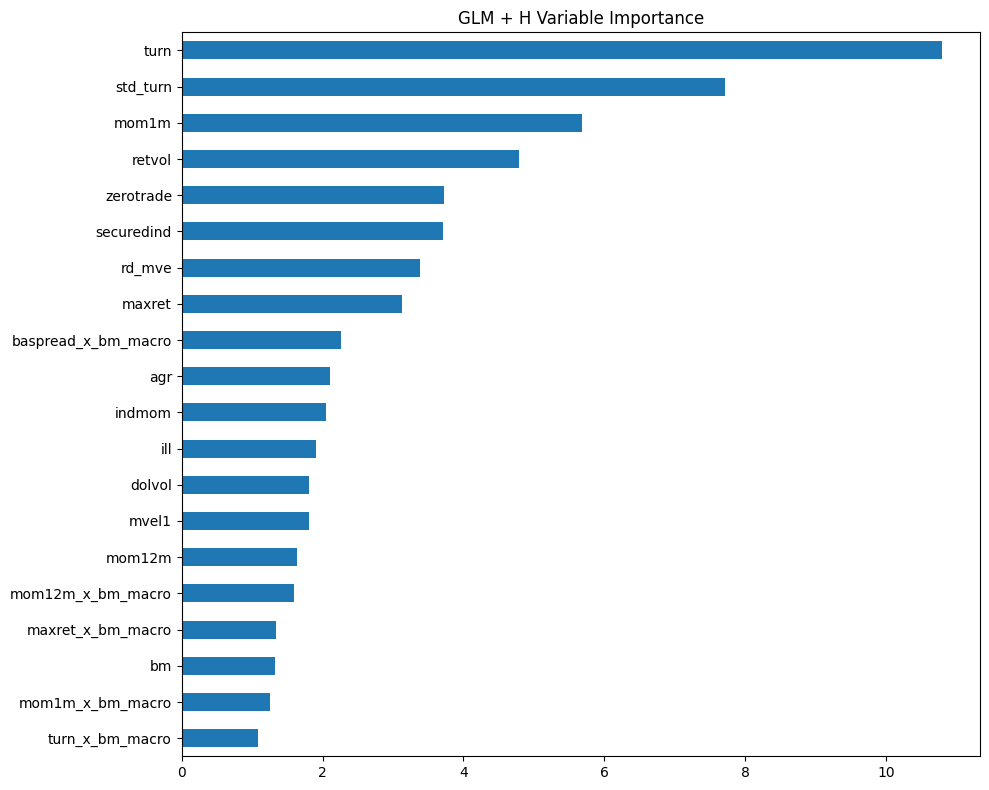

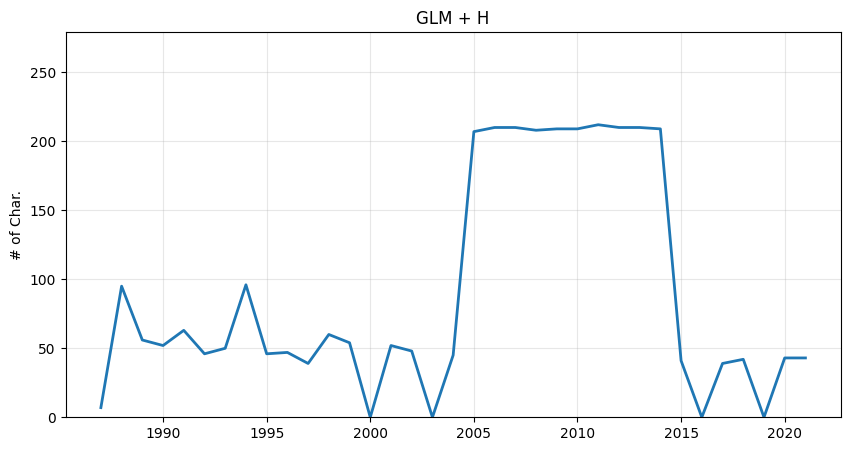

In [9]:
print("\nCalculating Variable Importance...")

if vi_sst_total <= 0:
    raise RuntimeError("Variable importance was not accumulated during the recursive loop.")

vi_series = vi_weighted_sum / vi_sst_total
vi_pct = (vi_series / vi_series.sum()) * 100 if vi_series.sum() > 0 else vi_series

plt.figure(figsize=(10, 8))
vi_pct.sort_values(ascending=False).head(20).sort_values().plot(kind='barh')
plt.xlim(left=0)
plt.title("GLM + H Variable Importance")
plt.tight_layout()
plt.show()

plot_model_selection_over_time(all_years, features_selected_count)

### 7. Monthly Performance

In [10]:
results_df = pl.DataFrame({
    "date": all_test_dates,
    "actual": all_actuals,
    "pred": all_preds,
    "me": all_test_me
})

summary = (
    results_df
    .with_columns(
        rank = pl.col("me").rank(descending=True).over("date")
    )
    .with_columns(
        group = (
            pl.when(pl.col("rank") <= 1000).then(pl.lit("Top1000"))
            .when(pl.col("rank") > (pl.col("rank").max().over("date") - 1000)).then(pl.lit("Bottom1000"))
            .otherwise(pl.lit("Middle"))
        )
    )
)

print("\n" + "="*35)
print(f"{'MONTHLY PERFORMANCE':^35}")
print("="*35)

for g in ["Full Sample", "Top1000", "Bottom1000"]:
    data = summary if g == "Full Sample" else summary.filter(pl.col("group") == g)

    print(f"{g:15} R2_oos: {r2_oos(
        data['actual'].to_numpy(),
        data['pred'].to_numpy()
    ):.4%}")

print("="*35)



        MONTHLY PERFORMANCE        
Full Sample     R2_oos: 0.2709%
Top1000         R2_oos: 0.5654%
Bottom1000      R2_oos: -0.0720%


### 8. Annual Performance

In [11]:
print("\n" + "="*45)
print(f"{'ANNUAL PERFORMANCE (TABLE 2)':^45}")
print("="*45)

df_annual = pd.DataFrame({
    'permno': all_test_permno,
    'year': pd.to_datetime(all_test_dates).year,   
    'actual': all_actuals,
    'pred': all_preds,
    'me': all_test_me
})

annual = (
    df_annual
    .groupby(['permno', 'year'])
    .agg({'actual': 'sum', 'pred': 'sum', 'me': 'first'})
    .reset_index()
)

annual['rank'] = annual.groupby('year')['me'].rank(ascending=False)
annual['max_rank'] = annual.groupby('year')['rank'].transform('max')

for label, mask in [
    ("Full Annual", annual['rank'] > 0),
    ("Top 1000", annual['rank'] <= 1000),
    ("Bottom 1000", annual['rank'] > annual['max_rank'] - 1000)
]:
    sub = annual[mask]

    print(f"{label:20} R2_oos: {r2_oos(
        sub['actual'].values,
        sub['pred'].values
    ):.4%}")

print("="*45)



        ANNUAL PERFORMANCE (TABLE 2)         
Full Annual          R2_oos: 0.0566%
Top 1000             R2_oos: 2.1705%
Bottom 1000          R2_oos: 0.6112%


### 9. Diebold Mariano Test

In [12]:
print("\nGenerating Monthly Error Series for DM Test...")

dm_export = pd.DataFrame({
    "date": all_test_dates,
    "sq_error": (np.array(all_actuals) - np.array(all_preds))**2
})

monthly_mse = (
    dm_export
    .groupby("date")["sq_error"]
    .mean()
    .reset_index()
)

monthly_mse.columns = ["date", "lasso_mse"]
monthly_mse.to_csv("lasso_dm_series.csv", index=False)

print("Saved 'lasso_dm_series.csv' for DM testing.")



Generating Monthly Error Series for DM Test...
Saved 'lasso_dm_series.csv' for DM testing.


### 10. Marginal Association Plots

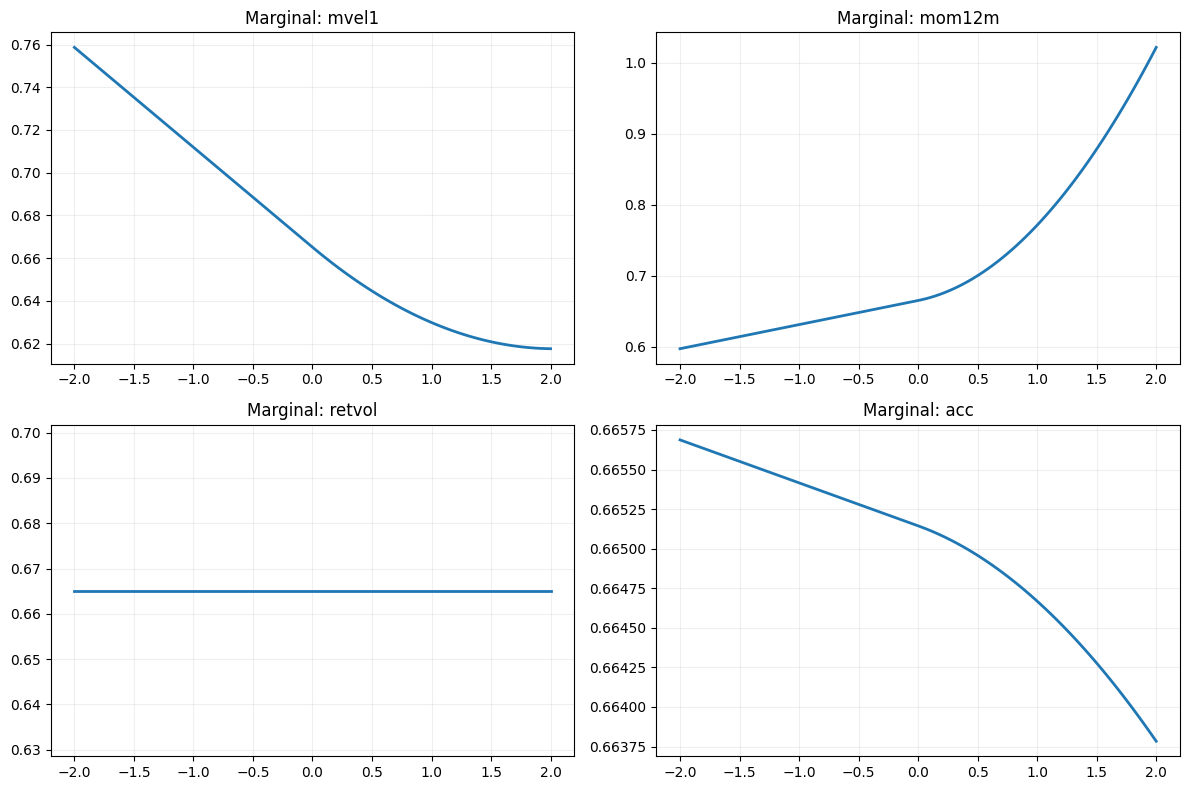

In [13]:
target_vars = ["mvel1", "mom12m", "retvol", "acc"]

plt.figure(figsize=(12, 8))

for i, var in enumerate([v for v in target_vars if v in feature_cols]):
    plt.subplot(2, 2, i + 1)

    xr = np.linspace(-2, 2, 100)
    Xm = np.zeros((100, len(feature_cols)), dtype=np.float32)  

    Xm[:, feature_cols.index(var)] = xr

    Xm_spline = get_gkx_spline_k3(Xm, spline_feature_mask)
    Xm_spline[:, 1:] = spline_scaler_last.transform(Xm_spline[:, 1:]).astype(np.float32, copy=False)
    ym = final_model.predict(Xm_spline).flatten() * 100

    plt.plot(xr, ym, lw=2)
    plt.title(f"Marginal: {var}")
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 11. Save Stock-Level OOS Predictions

Save the full out-of-sample prediction panel with stock identifiers. This is the durable input for bottom-up portfolio replication and model comparisons.


In [14]:
from pathlib import Path

# Mount Google Drive when running in Colab.
if Path("/content").exists():
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

PREDICTION_SOURCE = "glm_3"
SOURCE_NOTEBOOK = "Notebooks for Methodology/glm 3.ipynb"
SOURCE_PANEL = PATH
MODEL_NAME = "GLM_GroupLasso_Spline"

output_dir = Path("/content/drive/MyDrive/Replication Paper/Data/Results") / PREDICTION_SOURCE
output_dir.mkdir(parents=True, exist_ok=True)

n_predictions = len(all_preds)
if "all_test_exchcd" not in globals() or len(all_test_exchcd) != n_predictions:
    all_test_exchcd = [np.nan] * n_predictions
if "all_test_best_lam" not in globals() or len(all_test_best_lam) != n_predictions:
    all_test_best_lam = [np.nan] * n_predictions
if "all_test_active_features" not in globals() or len(all_test_active_features) != n_predictions:
    all_test_active_features = [np.nan] * n_predictions

glm_oos_predictions = pd.DataFrame({
    "source_notebook": SOURCE_NOTEBOOK,
    "source_panel": SOURCE_PANEL,
    "prediction_source": PREDICTION_SOURCE,
    "prediction_scope": "stock_level_oos_with_ids_for_bottom_up_portfolios",
    "model": MODEL_NAME,
    "test_year": pd.to_datetime(all_test_dates).year.astype("int16"),
    "date": all_test_dates,
    "permno": all_test_permno,
    "exchcd": all_test_exchcd,
    "me": all_test_me,
    "ret_excess": all_actuals,
    "actual": all_actuals,
    "prediction": all_preds,
    "predicted": all_preds,
    "best_lambda": all_test_best_lam,
    "active_features": all_test_active_features,
})

glm_oos_predictions["date"] = pd.to_datetime(glm_oos_predictions["date"])
glm_oos_predictions = glm_oos_predictions.sort_values(["date", "permno"]).reset_index(drop=True)

prediction_path = output_dir / f"{PREDICTION_SOURCE}_stock_level_oos_predictions_with_ids.parquet"
manifest_path = output_dir / f"{PREDICTION_SOURCE}_prediction_manifest.csv"

glm_oos_predictions.to_parquet(prediction_path, index=False)

manifest = pd.DataFrame([{
    "prediction_source": PREDICTION_SOURCE,
    "source_notebook": SOURCE_NOTEBOOK,
    "source_panel": SOURCE_PANEL,
    "model": MODEL_NAME,
    "file_type": "stock_level_oos_predictions_with_ids",
    "path": str(prediction_path),
    "rows": len(glm_oos_predictions),
    "columns": ",".join(glm_oos_predictions.columns),
}])
manifest.to_csv(manifest_path, index=False)

print(f"Saved GLM stock-level OOS predictions: {prediction_path}")
print(f"Saved GLM prediction manifest: {manifest_path}")
print(f"Prediction panel shape: {glm_oos_predictions.shape}")
print(glm_oos_predictions[["model", "permno", "date", "ret_excess", "prediction", "me", "exchcd"]].head())


Saved GLM stock-level OOS predictions: /content/drive/MyDrive/Replication Paper/Data/Results/glm_3/glm_3_stock_level_oos_predictions_with_ids.parquet
Saved GLM prediction manifest: /content/drive/MyDrive/Replication Paper/Data/Results/glm_3/glm_3_prediction_manifest.csv
Prediction panel shape: (2136916, 16)
                   model  permno       date  ret_excess  prediction  \
0  GLM_GroupLasso_Spline   10000 1987-01-01   -0.216272    0.000966   
1  GLM_GroupLasso_Spline   10001 1987-01-01   -0.039865    0.000763   
2  GLM_GroupLasso_Spline   10002 1987-01-01    0.091809    0.000894   
3  GLM_GroupLasso_Spline   10003 1987-01-01    0.125719    0.000856   
4  GLM_GroupLasso_Spline   10005 1987-01-01    0.662516    0.000771   

          me  exchcd  
0   1.581531       3  
1   6.689250       3  
2  15.935938       3  
3  47.523750       3  
4   0.722812       3  
